# Ejercicios Prácticos - PyTorch

##### II DIPLOMA DE EXPERTO EN APRENDIZAJE AUTOMÁTICO AVANZADO EN PYTHON
#### Alumno: Pablo Fazio Arrabal

---

## Ejercicios Básicos

1.  Utiliza PyTorch para realizar las siguientes tareas sobre el conjunto de datos CIFAR-10:
https://www.cs.toronto.edu/~kriz/cifar.html

    Para descargar las muestras puedes ayudarte del siguiente código:
    ```
    torchvision.datasets.CIFAR10(="./", train=True, download=True)
    ```

    **a)** Imprime por pantalla el tamaño de una de las imágenes originales y dibuja las diez primeras muestras del dataset en tamaño original junto con sus salidas deseadas.

    **b)** Extrae todas las muestras del dataset en forma de lista de imágenes para los rasgos y de enteros para las clases deseadas. Muestra la cantidad de elementos en ambas listas.

    **c)** Define un dataset personalizado que admita las listas de muestras del apartado anterior y que utilice un objeto transformador. Crea una instancia de la nueva clase, carga las muestras del apartado anterior y aplica:

    i) Redimensionamiento de los rasgos a 64x64 píxeles.

    ii) Conversión a tensor.

    **d)** Imprime por pantalla el tamaño de una muestra después de la transformación del
    apartado anterior.

    **e)** Crea un DataLoader para iterar sobre el conjunto de datos, el tamaño de lote será de diez elementos. Usa este DataLoader en un bucle que simule tres épocas de entrenamiento, tal y como hemos visto en la práctica guiada. Numera cada lote e imprime por pantalla las clases deseadas de aquellos lotes múltiplos de 1000. La salida debe ser parecido a esto:



<div align="center">

  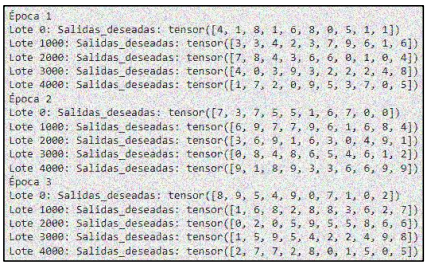

</div>


In [2]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Descargamos el dataset original de entrenamiento
cifar_dataset = torchvision.datasets.CIFAR10(root="./", train=True, download=True)

# Lista de etiquetas de texto correspondientes a las clases de CIFAR
clases_nombres = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']

100%|██████████| 170M/170M [00:05<00:00, 31.6MB/s]


Tamaño de una imagen original: (32, 32) píxeles.



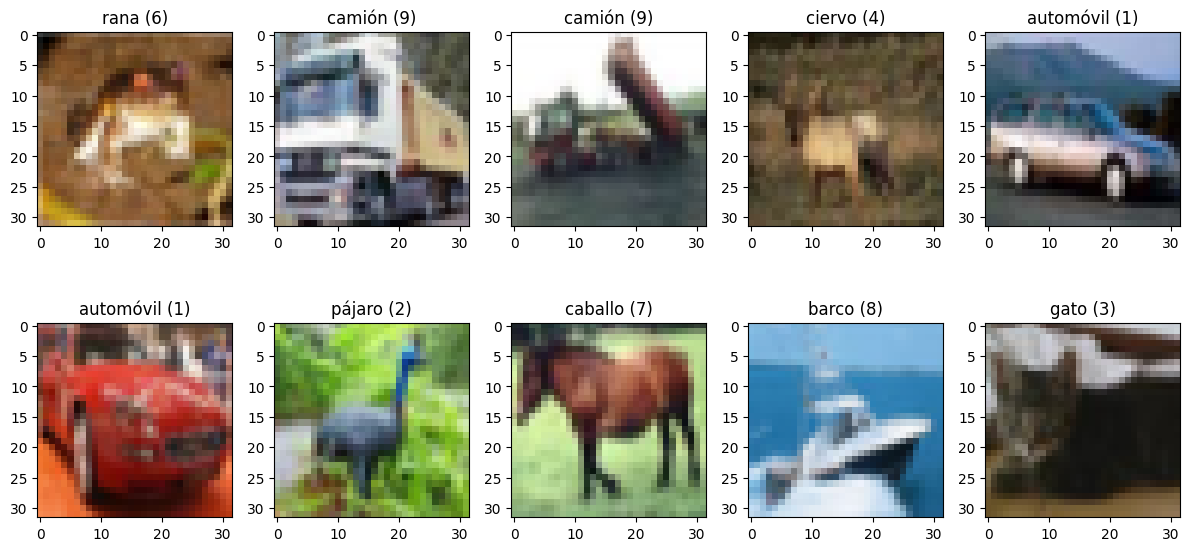

In [4]:
# APARTADO A)

# Obtenemos la primera muestra e imprimimos por pantalla su tamaño

primera_img, primera_etiqueta = cifar_dataset[0]

print(f"Tamaño de una imagen original: {primera_img.size} píxeles.\n")

# Dibujamos las 10 primeras muestras en una figura de 2x5

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    img, label = cifar_dataset[i]
    axes[i].imshow(img) # Mostrar la imagen original
    axes[i].set_title(f"{clases_nombres[label]} ({label})")

plt.tight_layout()
plt.show()

In [5]:
# APARTADO B)

# Extraemos los rasgos y las clases deseadas (enteros)

lista_imagenes = [muestra[0] for muestra in cifar_dataset]
lista_clases = [muestra[1] for muestra in cifar_dataset]

# Imprimimos la cantidad de elementos de ambas listas

print(f"Número de elementos en la lista de imágenes: {len(lista_imagenes)}")
print(f"Número de elementos en la lista de clases: {len(lista_clases)}")

Número de elementos en la lista de imágenes: 50000
Número de elementos en la lista de clases: 50000


In [6]:
# APARTADO C)

class CIFAR10Personalizado(Dataset):
    def __init__(self, imagenes, clases, transform=None):
        self.imagenes = imagenes
        self.clases = clases
        self.transform = transform

    def __len__(self):
        return len(self.imagenes) # Devuelve el total de muestras

    def __getitem__(self, idx):
        img = self.imagenes[idx]
        clase = self.clases[idx]

        # Si hay transformaciones definidas, se aplican a la imagen
        if self.transform:
            img = self.transform(img)

        return img, clase

In [7]:
# Definimos el objeto transformador compuesto
transformacion_compuesta = transforms.Compose([
    transforms.Resize((64, 64)), # Redimensiona a 64x64
    transforms.ToTensor()        # Convierte la imagen PIL a Tensor de PyTorch y escala a [0.0, 1.0]
])

# Creamos la instancia de nuestro dataset usando las listas de b)
dataset_transformado = CIFAR10Personalizado(
    imagenes=lista_imagenes,
    clases=lista_clases,
    transform=transformacion_compuesta
)

In [8]:
# APARTADO D)

# Obtención del primer elemento del nuevo dataset
img_transformada, etiqueta_transformada = dataset_transformado[0]

# Imprimimos el tamaño del tensor resultante
print(f"Tamaño de la muestra después de la transformación: {img_transformada.shape}")

Tamaño de la muestra después de la transformación: torch.Size([3, 64, 64])


In [10]:
# APARTADO E)

train_loader = DataLoader(dataset_transformado, batch_size=10, shuffle=True)
epocas = 3 # Número de épocas

for epoca in range(epocas):
    print(f"Época {epoca + 1}")

    # Iteramos sobre el DataLoader numerando cada lote
    for num_lote, (imagenes_lote, clases_lote) in enumerate(train_loader, start=0):

        # Comprobamos si el número de lote es múltiplo de 1000 para imprimir
        if num_lote % 1000 == 0:
            # Imprimimos las clases deseadas del lote
            print(f"Lote {num_lote}: Salidas_deseadas: {clases_lote}")

Época 1
Lote 0: Salidas_deseadas: tensor([9, 2, 9, 7, 3, 7, 4, 1, 4, 3])
Lote 1000: Salidas_deseadas: tensor([1, 1, 8, 6, 0, 0, 9, 0, 0, 8])
Lote 2000: Salidas_deseadas: tensor([0, 6, 2, 6, 0, 3, 0, 4, 6, 0])
Lote 3000: Salidas_deseadas: tensor([2, 6, 7, 0, 4, 4, 1, 5, 9, 9])
Lote 4000: Salidas_deseadas: tensor([7, 6, 3, 3, 4, 9, 9, 1, 1, 7])
Época 2
Lote 0: Salidas_deseadas: tensor([9, 7, 2, 3, 5, 5, 6, 7, 9, 0])
Lote 1000: Salidas_deseadas: tensor([4, 8, 1, 6, 9, 8, 3, 1, 3, 8])
Lote 2000: Salidas_deseadas: tensor([6, 7, 4, 1, 2, 1, 9, 2, 9, 0])
Lote 3000: Salidas_deseadas: tensor([9, 8, 0, 7, 6, 0, 2, 1, 2, 8])
Lote 4000: Salidas_deseadas: tensor([1, 9, 5, 7, 5, 2, 7, 2, 0, 2])
Época 3
Lote 0: Salidas_deseadas: tensor([2, 1, 3, 4, 2, 0, 9, 5, 7, 5])
Lote 1000: Salidas_deseadas: tensor([0, 0, 7, 5, 9, 5, 0, 4, 2, 6])
Lote 2000: Salidas_deseadas: tensor([0, 1, 0, 3, 7, 5, 4, 2, 0, 3])
Lote 3000: Salidas_deseadas: tensor([8, 0, 5, 5, 2, 9, 5, 8, 2, 9])
Lote 4000: Salidas_deseadas: tens

2.  Entrena una red MLP con PyTorch que clasifique las prendas de ropa de Zalando disponibles en el dataset Fashion-MNIST: https://www.tensorflow.org/datasets/catalog/fashion_mnist?hl=es

    Para descargar las muestras puedes basarte en este código:

    ```
    ent_dataset = torchvision.datasets.FashionMNIST(root="./",
    train=True, transform=transformacion, download=True)
    val_dataset = torchvision.datasets.FashionMNIST(root="./",
    train=False, transform= transformacion, download=True)
    ```

    **a)** Carga el dataset torchvision.datasets.FashionMNIST, que contiene imágenes de diferentes prendas de ropa (camisetas, pantalones, zapatos, etc.).

    **b)** Preprocesa los datos aplanando las entradas y asegurándote de que estén normalizadas.

    **c)** Define una MLP con:

    i) Dos capas ocultas de 128 y 64 neuronas de tipo Sigmoid.

    ii) Una capa de salida que se adapte al tipo de problema.

    **d)** Entrena el modelo durante diez épocas de entrenamiento usando:

    i) Optimizador SGD.

    ii) Función de pérdida adecuada considerando el problema.

    **e)** Representa gráficamente la pérdida y exactitud del modelo a lo largo de las épocas de entrenamiento, tanto en entrenamiento como en validación, tal y como se ha hecho en las prácticas guiadas. Comenta los resultados obtenidos.

    **f)** Considerando las cinco primeras muestras de validación, calcula para cada una de ellas la probabilidad de pertenecer a cada clase.

    **g)** De las cinco muestras del apartado anterior y, considerando el modelo que has entrenado, ¿en qué muestra hay más dudas sobre su pertenencia a la clase predicha?


In [23]:
# APARTADOS A) y B)

import torch

# Definimos el objeto transformador (Normaliza a [0,1] y aplana la imagen)
transformacion = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

clases_prendas = ['Camiseta', 'Pantalón', 'Pullover', 'Vestido', 'Abrigo',
                  'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Carga de los datasets de entrenamiento y validación
ent_dataset = torchvision.datasets.FashionMNIST(root="./", train=True, transform=transformacion, download=True)
val_dataset = torchvision.datasets.FashionMNIST(root="./", train=False, transform=transformacion, download=True)

In [15]:
# APARTADO C)

import torch.nn as nn
import torch.optim as optim

class MLPClasificador(nn.Module):
    def __init__(self):
        super(MLPClasificador, self).__init__()

        self.estructura = nn.Sequential(
            nn.Linear(784, 128),  # Capa de entrada -> Primera capa oculta
            nn.Sigmoid(),
            nn.Linear(128, 64),   # Primera capa oculta -> Segunda capa oculta
            nn.Sigmoid(),
            nn.Linear(64, 10)     # Segunda capa oculta -> Capa de salida
        )

    def forward(self, x):
        return self.estructura(x)

In [18]:
def entrenar(modelo_red, num_epocas, ent_dataloader, X_valid, y_valid,
             func_perdida, optimizador, clasificacion=False):
  """
  Parámetros:
    ----------
    modelo_red : torch.nn.Module
        El modelo de red neuronal a entrenar.
    num_epocas : int
        Número de épocas para entrenar el modelo.
    ent_dataloader : torch.utils.data.DataLoader
        DataLoader que contiene los lotes del conjunto de entrenamiento.
    X_valid : torch.Tensor
        Tensor con las características del conjunto de validación.
    y_valid : torch.Tensor
        Tensor con las etiquetas del conjunto de validación (vector)
    loss_fn : callable
        Función de pérdida utilizada para calcular el error entre las predicciones y las etiquetas.
    optimizador : torch.optim.Optimizer
        Optimizador que actualiza los parámetros del modelo.
    clasificacion : bool, opcional (por defecto False)
        Si es True, calcula la exactitud además de la pérdida.

    Devuelve:
    -------
    loss_hist_ent : list[float]
        Lista con la pérdida promedio de entrenamiento por época.
    loss_hist_val : list[float]
        Lista con la pérdida promedio de validación por época.
    exact_hist_ent : list[float]
        Lista con la precisión promedio de entrenamiento por época (si clasificacion=True).
    exact_hist_val : list[float]
        Lista con la precisión promedio de validación por época (si clasificacion=True).
  """
  # Creamos listas para almacenar las métricas de entrenamiento y validación para cada época
  # 'loss' para la función de pérdida, 'exact' para la exactitud
  loss_hist_ent = [0] * num_epocas
  exact_hist_ent = [0] * num_epocas
  loss_hist_val = [0] * num_epocas
  exact_hist_val = [0] * num_epocas

  # Iniciamos el bucle de entrenamiento para todas las épocas
  for epoca in range(num_epocas):
    # Bucle a través de los lotes de entrenamiento (ent_dataloader)
    for x_lote, y_lote in ent_dataloader:
      # FORWARD #
      # Realizamos la predicción en el lote actual
      pred = modelo_red(x_lote)
      # Si la salida predicha es un vector  (una única neurona de salida)
      if (pred.size(1)==1):
        # Eliminamos la última dimensión (es equivalente y evitamos problemas sintácticos)
        pred = pred[:, 0]

      # Calculamos la pérdida (loss) usando la función de pérdida especificada
      loss = func_perdida(pred, y_lote)

      # BACKWARD
      loss.backward()
      optimizador.step()
      optimizador.zero_grad()

      # RENDIMIENTOS en entrenamiento
      # Acumulamos la pérdida media del entrenamiento para este lote
      loss_hist_ent[epoca] += loss.item()

      if clasificacion:
        if pred.dim()==1:  # 1 neurona => clasificación binaria
          if isinstance(func_perdida, nn.BCELoss): # Para BCELoss, con sigmoide explícita
            clase_pred = (pred >= 0.5).float()
          else:  # Para BCEWithLogitLoss, sin sigmoide explícita, la salida es un logit
            clase_pred = (pred >= 0.0).float()
        else:  # Varias neuronas de salida => clasificación múltiple
          clase_pred = torch.argmax(pred, dim=1)
        correcto = (clase_pred == y_lote).float()
        # Calculamos exactitud media de entrenamiento del lote
        exact_hist_ent[epoca] += correcto.mean().item()

    # Promediamos la pérdida y la precisión de entrenamiento para toda la
    # época dividiendo por el número de lotes
    loss_hist_ent[epoca] /= len(ent_dataloader)
    if clasificacion:
      exact_hist_ent[epoca] /= len(ent_dataloader)

    # RENDIMIENTOS en validación
    with torch.no_grad():
      pred = modelo_red(X_valid)
      if (pred.size(1)==1):
        pred = pred[:, 0]
      loss = func_perdida(pred, y_valid)

      # Almacenamos la pérdida media en validación
      loss_hist_val[epoca] = loss.item()
      # Si es un problema de clasificación => calculamos exactitudes
      if clasificacion:
        if pred.dim()==1: # Binaria
          if isinstance(func_perdida, nn.BCELoss): # Para BCELoss, con sigmoide explícita
            clase_pred = (pred >= 0.5).float()
          else:  # Para BCELossWithLogits, sin sigmoide explícita, la salida es un logit
            clase_pred = (pred >= 0.0).float()
        else:             # Multiclase
          clase_pred = torch.argmax(pred, dim=1)
        correcto = (clase_pred == y_valid).float()
        # Almacenamos la exactitud media en validación
        exact_hist_val[epoca] = correcto.mean().item()

    # Imprimir métricas cada cierto número de épocas (opcional)
    if (epoca + 1) % 10 == 0:
      print(f"Época {epoca + 1}/{num_epocas} | Pérdida Entrenamiento: {loss_hist_ent[epoca]:.4f} | "
            f"Pérdida Validación: {loss_hist_val[epoca]:.4f} | "
            f"Exactitud Entrenamiento: {exact_hist_ent[epoca]:.4f} | "
            f"Exactitud Validación: {exact_hist_val[epoca]:.4f}")

  # Retornamos las métricas de pérdida y precisión para el entrenamiento y la validación
  return loss_hist_ent, loss_hist_val, exact_hist_ent, exact_hist_val

In [21]:
# APARTADO D)

torch.manual_seed(1)

# Creamos una instancia del MLP definido
modelo = MLPClasificador()

# Optimizador SGD con una tasa de aprendizaje de 0.1
optimizador = optim.SGD(modelo.parameters(), lr=0.1)

# Función de pérdida: usaremos entropía cruzada para clasificación
loss_fn = nn.CrossEntropyLoss()

# Creamos el DataLoader únicamente para el conjunto de entrenamiento (como requiere la función)
ent_loader = DataLoader(ent_dataset, batch_size=64, shuffle=True)

# Extraemos la validación al completo en dos tensores
X_val_tensor = torch.stack([muestra[0] for muestra in val_dataset])
y_val_tensor = torch.tensor([muestra[1] for muestra in val_dataset])

num_epocas = 10

# Llamada a la función entrenar()
historico = entrenar(modelo, num_epocas, ent_loader, X_val_tensor, y_val_tensor,
                     loss_fn, optimizador, True)

Época 10/10 | Pérdida Entrenamiento: 0.4170 | Pérdida Validación: 0.4545 | Exactitud Entrenamiento: 0.8510 | Exactitud Validación: 0.8374


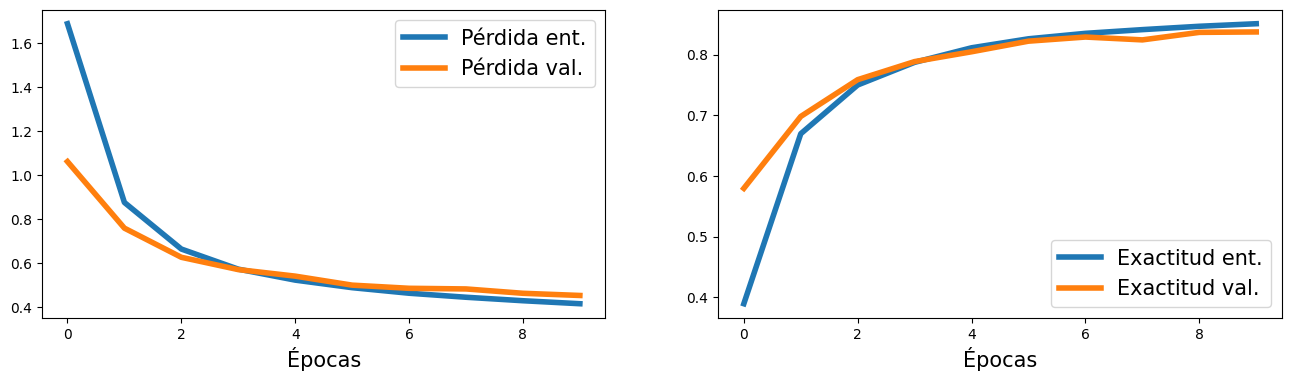

In [22]:
# APARTADO E)

fig = plt.figure(figsize=(16, 4))

ax = fig.add_subplot(1, 2, 1)
plt.plot(historico[0], lw=4) # Pérdida entrenamiento
plt.plot(historico[1], lw=4) # Pérdida validación
plt.legend(['Pérdida ent.', 'Pérdida val.'], fontsize=15)
ax.set_xlabel('Épocas', size=15)

ax = fig.add_subplot(1, 2, 2)
plt.plot(historico[2], lw=4) # Exactitud entrenamiento
plt.plot(historico[3], lw=4) # Exactitud validación
plt.legend(['Exactitud ent.', 'Exactitud val.'], fontsize=15)
ax.set_xlabel('Épocas', size=15)

plt.show()

Las curvas de pérdida disminuyen progresivamente de forma simétrica a la par que los dos gráficos de exactitud aumentan de forma estable rebasando el 80% de acierto.

Como la validación no se separa hacia arriba de la línea azul de entrenamiento en el gráfico de pérdidas, podemos afirmar que el modelo generaliza correctamente y no tiene sobreajuste durante las 10 épocas.

In [24]:
# APARTADO F)

modelo.eval()

# Tomamos las 5 primeras muestras directamente de los tensores de validación
X_5_muestras = X_val_tensor[:5]
y_5_reales = y_val_tensor[:5].numpy() # Lo pasamos a NumPy para poder imprimirlo fácilmente

with torch.no_grad():
    logits_5 = modelo(X_5_muestras)
    # Aplicamos Softmax para convertir los resultados en probabilidades de 0.0 a 1.0
    probabilidades_5 = torch.softmax(logits_5, dim=1)

probabilidades_np = probabilidades_5.numpy()

for i in range(5):
    print(f"\n--- Muestra {i+1} [Clase Real: {clases_prendas[y_5_reales[i]]}] ---")
    clase_predicha = np.argmax(probabilidades_np[i])
    print(f"Predicción del modelo: {clases_prendas[clase_predicha]} (Confianza: {probabilidades_np[i][clase_predicha]:.4f})")
    print("Probabilidades por clase:")
    for idx_c, prob in enumerate(probabilidades_np[i]):
        print(f"  {clases_prendas[idx_c]}: {prob:.4f}")


--- Muestra 1 [Clase Real: Botín] ---
Predicción del modelo: Botín (Confianza: 0.8547)
Probabilidades por clase:
  Camiseta: 0.0000
  Pantalón: 0.0000
  Pullover: 0.0000
  Vestido: 0.0000
  Abrigo: 0.0000
  Sandalia: 0.0587
  Camisa: 0.0000
  Zapatilla: 0.0835
  Bolso: 0.0030
  Botín: 0.8547

--- Muestra 2 [Clase Real: Pullover] ---
Predicción del modelo: Pullover (Confianza: 0.9064)
Probabilidades por clase:
  Camiseta: 0.0037
  Pantalón: 0.0005
  Pullover: 0.9064
  Vestido: 0.0001
  Abrigo: 0.0140
  Sandalia: 0.0002
  Camisa: 0.0748
  Zapatilla: 0.0000
  Bolso: 0.0001
  Botín: 0.0000

--- Muestra 3 [Clase Real: Pantalón] ---
Predicción del modelo: Pantalón (Confianza: 0.9994)
Probabilidades por clase:
  Camiseta: 0.0001
  Pantalón: 0.9994
  Pullover: 0.0000
  Vestido: 0.0004
  Abrigo: 0.0000
  Sandalia: 0.0000
  Camisa: 0.0000
  Zapatilla: 0.0000
  Bolso: 0.0000
  Botín: 0.0000

--- Muestra 4 [Clase Real: Pantalón] ---
Predicción del modelo: Pantalón (Confianza: 0.9994)
Probabilidad

**APARTADO G)**

Visualizando los resultados, la **muestra número 5**, tiene una confianza del 0.68 que es mucho menor al resto de muestras por lo que hay más dudas de que realmente sea una camisa. Esto es debido a que la camiseta o el pullover tiene una probabilidad alta.

## Ejercicio Avanzado

3. Usa la misma arquitectura de red MLP y parámetros de entrenamiento, y la misma base de datos Fashion-MNIST del ejercicio anterior.

    **a)** Entrena 10 MLPs. Cada MLP usará un subconjunto elegido aleatoriamente del conjunto de entrenamiento de Fashion-MNIST. El primer MLP usará el 10% de las muestras del conjunto de entrenamiento, el segundo MLP usará el 20%, y así sucesivamente hasta el décimo MLP que usará todas las muestras (100%) del conjunto de entrenamiento.

    **b)** Representa gráficamente la pérdida y exactitud de cada modelo al final de su entrenamiento, tanto en entrenamiento como en validación. El eje horizontal de cada gráfica debe ser el porcentaje de muestras usadas. El eje vertical de cada gráfica debe ser el rendimiento (pérdida o exactitud). Comenta los resultados obtenidos.

In [25]:
# APARTADO A)

from torch.utils.data import Subset

porcentajes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

final_loss_ent = []
final_loss_val = []
final_exact_ent = []
final_exact_val = []

num_epocas = 10
total_muestras = len(ent_dataset)

for p in porcentajes:

    # Calculamos cuántas muestras representan este porcentaje
    num_muestras_sub = int(total_muestras * (p / 100))

    indices_aleatorios = np.random.choice(total_muestras, num_muestras_sub, replace=False)

    # Creamos el subconjunto reducido
    subconjunto_ent = Subset(ent_dataset, indices_aleatorios)

    # Creamos el dataloader para el subconjunto
    sub_loader = DataLoader(subconjunto_ent, batch_size=64, shuffle=True)

    # Inicializar nuevo modelo
    modelo_p = MLPClasificador()
    optimizador_p = optim.SGD(modelo_p.parameters(), lr=0.1)
    loss_fn = nn.CrossEntropyLoss()

    # Entrenamos el modelo actual durante 10 épocas usando entrenar()
    historico = entrenar(modelo_p, num_epocas, sub_loader, X_val_tensor, y_val_tensor,
                         loss_fn, optimizador_p, clasificacion=True)

    # Guardamos el rendimiento final
    final_loss_ent.append(historico[0][-1])
    final_loss_val.append(historico[1][-1])
    final_exact_ent.append(historico[2][-1])
    final_exact_val.append(historico[3][-1])

Época 10/10 | Pérdida Entrenamiento: 1.0669 | Pérdida Validación: 1.0398 | Exactitud Entrenamiento: 0.6096 | Exactitud Validación: 0.6298
Época 10/10 | Pérdida Entrenamiento: 0.7478 | Pérdida Validación: 0.7529 | Exactitud Entrenamiento: 0.7318 | Exactitud Validación: 0.7186
Época 10/10 | Pérdida Entrenamiento: 0.6175 | Pérdida Validación: 0.6350 | Exactitud Entrenamiento: 0.7702 | Exactitud Validación: 0.7544
Época 10/10 | Pérdida Entrenamiento: 0.5597 | Pérdida Validación: 0.5730 | Exactitud Entrenamiento: 0.7931 | Exactitud Validación: 0.7911
Época 10/10 | Pérdida Entrenamiento: 0.5310 | Pérdida Validación: 0.5367 | Exactitud Entrenamiento: 0.8104 | Exactitud Validación: 0.8062
Época 10/10 | Pérdida Entrenamiento: 0.4903 | Pérdida Validación: 0.5160 | Exactitud Entrenamiento: 0.8233 | Exactitud Validación: 0.8095
Época 10/10 | Pérdida Entrenamiento: 0.4678 | Pérdida Validación: 0.5111 | Exactitud Entrenamiento: 0.8340 | Exactitud Validación: 0.8157
Época 10/10 | Pérdida Entrenamient

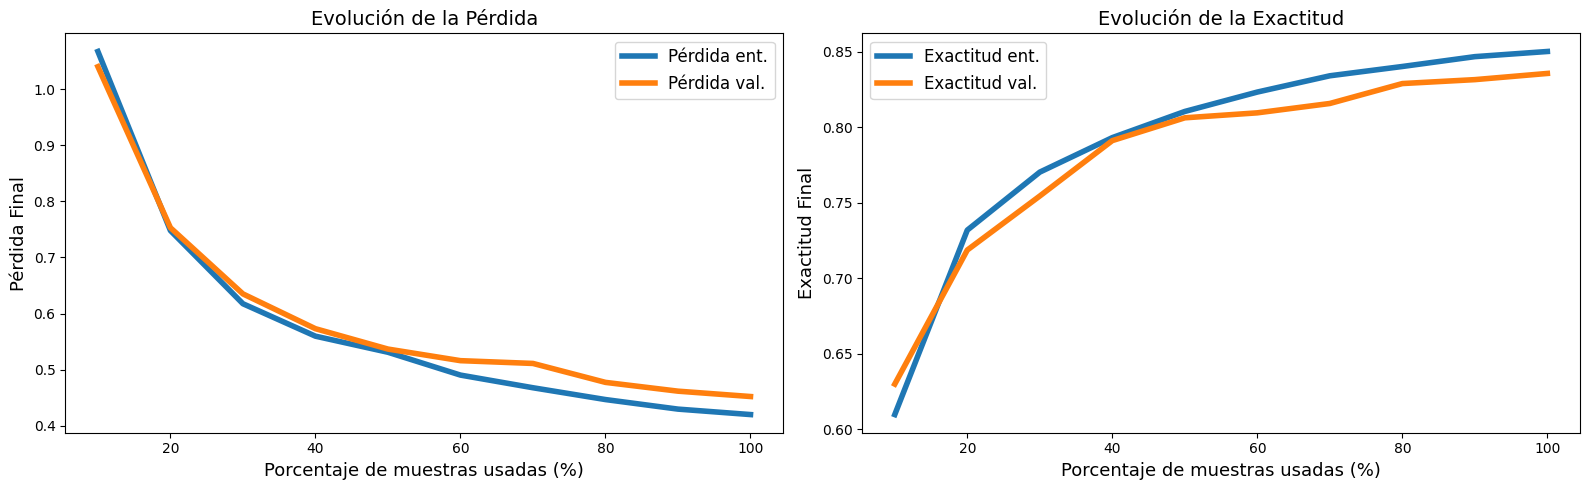

In [26]:
# APARTADO B)

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 2, 1)
plt.plot(porcentajes, final_loss_ent, lw=4, label='Pérdida ent.')
plt.plot(porcentajes, final_loss_val, lw=4, label='Pérdida val.')
plt.legend(fontsize=12)
ax1.set_xlabel('Porcentaje de muestras usadas (%)', size=13)
ax1.set_ylabel('Pérdida Final', size=13)
ax1.set_title('Evolución de la Pérdida', size=14)

ax2 = fig.add_subplot(1, 2, 2)
plt.plot(porcentajes, final_exact_ent, lw=4, label='Exactitud ent.')
plt.plot(porcentajes, final_exact_val, lw=4, label='Exactitud val.')
plt.legend(fontsize=12)
ax2.set_xlabel('Porcentaje de muestras usadas (%)', size=13)
ax2.set_ylabel('Exactitud Final', size=13)
ax2.set_title('Evolución de la Exactitud', size=14)

plt.tight_layout()
plt.show()

A medida que aumentamos el porcentaje de muestras de entrenamiento (del 10% al 100%), la exactitud de validación mejora de forma notable y la pérdida en validación disminuye.

La red MLP necesita una cantidad sustancial de ejemplos (preferiblemente el 100% del dataset) para generalizar correctamente y ser robusta frente a datos reales de validación.

## Ejercicio Experto

4. Usa la misma base de datos Fashion-MNIST del ejercicio anterior.

    **a)** Define 7 MLPs con:
    
    i) Dos capas ocultas de neuronas de tipo Sigmoid. Los tamaños de las capas ocultas para cada MLP serán: `[32, 16], [48, 24], [64, 32], [96, 48], [128, 64], [192, 96], [256, 128]`
    
    ii) Una capa de salida que se adapte al tipo de problema.

    **b)** Entrena cada uno de los 7 modelos durante diez épocas de entrenamiento, empleando todas las muestras de entrenamiento disponibles, usando:

    i) Optimizador SGD.

    ii) Función de pérdida adecuada considerando el problema.

    **c)** Representa gráficamente la pérdida y exactitud de cada modelo al final de su entrenamiento, tanto en entrenamiento como en validación. El eje horizontal de cada gráfica debe ser el número de neuronas de la primera capa del modelo. El eje vertical de cada gráfica debe ser el rendimiento (pérdida o exactitud). Comenta los resultados obtenidos.


In [27]:
# APARTADO A)

# Lista de tuplas con [Capa Oculta 1, Capa Oculta 2]
arquitecturas = [[32, 16], [48, 24], [64, 32], [96, 48], [128, 64], [192, 96], [256, 128]]
eje_x_neuronas = [arq[0] for arq in arquitecturas]

# Listas para almacenar el rendimiento de la última época (época 10) de cada MLP
final_loss_ent = []
final_loss_val = []
final_exact_ent = []
final_exact_val = []

In [28]:
class MLPVariable(nn.Module):
    def __init__(self, neuronas_h1, neuronas_h2):
        super(MLPVariable, self).__init__()
        self.estructura = nn.Sequential(
            nn.Linear(784, neuronas_h1),  # Entrada -> Primera capa oculta
            nn.Sigmoid(),
            nn.Linear(neuronas_h1, neuronas_h2), # Primera capa -> Segunda capa oculta
            nn.Sigmoid(),
            nn.Linear(neuronas_h2, 10)    # Segunda capa -> Capa de salida (10 clases)
        )

    def forward(self, x):
        return self.estructura(x)

In [29]:
# APARTADO B)

num_epocas = 10

for arq in arquitecturas:
    h1, h2 = arq[0], arq[1]

    # Instanciamos el modelo con su tamaño correspondiente
    modelo_arq = MLPVariable(h1, h2)
    optimizador_arq = optim.SGD(modelo_arq.parameters(), lr=0.1)
    loss_fn = nn.CrossEntropyLoss()

    historico = entrenar(modelo_arq, num_epocas, ent_loader, X_val_tensor, y_val_tensor,
                         loss_fn, optimizador_arq, clasificacion=True)

    # Extraemos y guardamos los resultados finales obtenidos en la época 10
    final_loss_ent.append(historico[0][-1])
    final_loss_val.append(historico[1][-1])
    final_exact_ent.append(historico[2][-1])
    final_exact_val.append(historico[3][-1])

Época 10/10 | Pérdida Entrenamiento: 0.4435 | Pérdida Validación: 0.4631 | Exactitud Entrenamiento: 0.8439 | Exactitud Validación: 0.8381
Época 10/10 | Pérdida Entrenamiento: 0.4174 | Pérdida Validación: 0.4448 | Exactitud Entrenamiento: 0.8532 | Exactitud Validación: 0.8439
Época 10/10 | Pérdida Entrenamiento: 0.4208 | Pérdida Validación: 0.4537 | Exactitud Entrenamiento: 0.8502 | Exactitud Validación: 0.8406
Época 10/10 | Pérdida Entrenamiento: 0.4168 | Pérdida Validación: 0.4557 | Exactitud Entrenamiento: 0.8517 | Exactitud Validación: 0.8364
Época 10/10 | Pérdida Entrenamiento: 0.4181 | Pérdida Validación: 0.4519 | Exactitud Entrenamiento: 0.8492 | Exactitud Validación: 0.8376
Época 10/10 | Pérdida Entrenamiento: 0.4269 | Pérdida Validación: 0.4572 | Exactitud Entrenamiento: 0.8470 | Exactitud Validación: 0.8348
Época 10/10 | Pérdida Entrenamiento: 0.4294 | Pérdida Validación: 0.4782 | Exactitud Entrenamiento: 0.8463 | Exactitud Validación: 0.8246


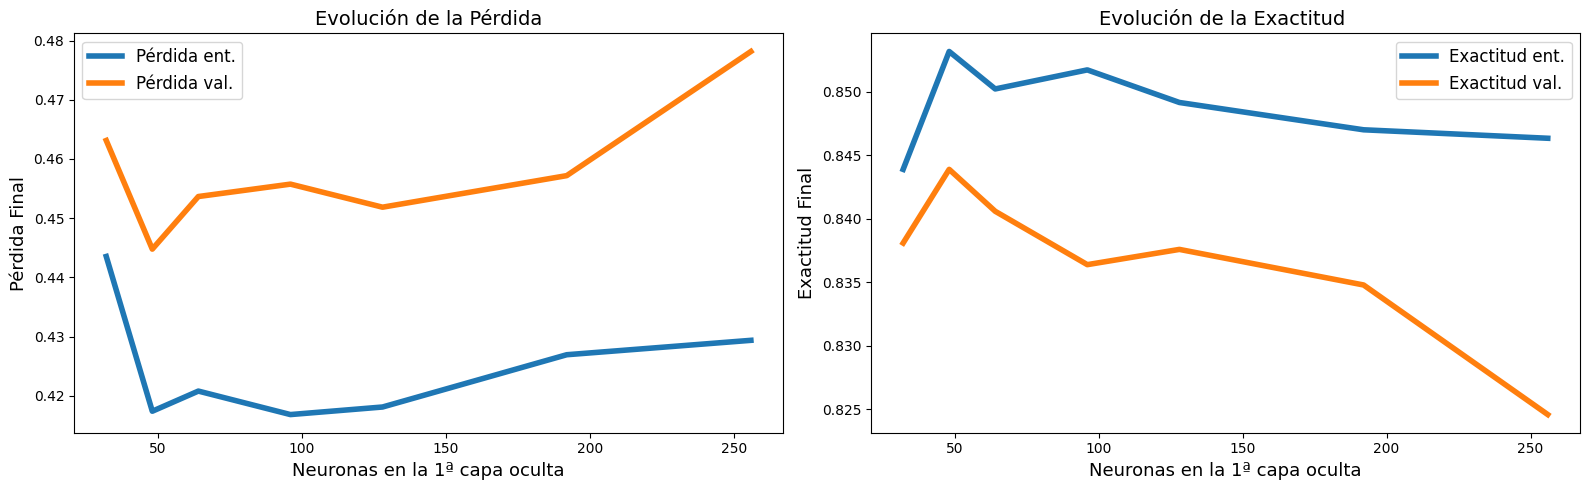

In [30]:
# APARTADO C)

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 2, 1)
plt.plot(eje_x_neuronas, final_loss_ent, lw=4, label='Pérdida ent.')
plt.plot(eje_x_neuronas, final_loss_val, lw=4, label='Pérdida val.')
plt.legend(fontsize=12)
ax1.set_xlabel('Neuronas en la 1ª capa oculta', size=13)
ax1.set_ylabel('Pérdida Final', size=13)
ax1.set_title('Evolución de la Pérdida', size=14)

ax2 = fig.add_subplot(1, 2, 2)
plt.plot(eje_x_neuronas, final_exact_ent, lw=4, label='Exactitud ent.')
plt.plot(eje_x_neuronas, final_exact_val, lw=4, label='Exactitud val.')
plt.legend(fontsize=12)
ax2.set_xlabel('Neuronas en la 1ª capa oculta', size=13)
ax2.set_ylabel('Exactitud Final', size=13)
ax2.set_title('Evolución de la Exactitud ', size=14)

plt.tight_layout()
plt.show()

El gráfico muestra que a mayor número de neuronas el rendimiento empeora, siendo la red más pequeña la que logra la menor pérdida y mayor exactitud. Este fenómeno ocurre porque las redes grandes se saturan y avanzan mucho más lento debido a la activación Sigmoid, quedándose atascadas en las 10 épocas de entrenamiento. Además, se observa una clara separación entre las curvas de entrenamiento y validación, donde la pérdida de validación siempre se mantiene por encima; esto confirma que las redes grandes sufren una falta de convergencia y no consiguen aprender los patrones generales en un tiempo tan corto.